In [17]:
#importiamo le librerie di base
import numpy as np 
import pandas as pd 
import librosa.display  
import matplotlib.pyplot as plt  
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer  # Importa PowerTransformer
from sklearn.preprocessing import QuantileTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score, hinge_loss
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
import time
from sklearn.metrics import classification_report



In [6]:
pd.set_option('display.max_columns', None)  #per stampare tutte le colonne
music_data_original = pd.read_csv('Data/features_3_sec.csv') 


colonne=music_data_original.columns.size
print(f'IL DATASET PRESO UN CONSIDERAZIONE HA {colonne} PER OGNI CAMPIONE')
music_data_original.head(5) 


IL DATASET PRESO UN CONSIDERAZIONE HA 60 PER OGNI CAMPIONE


,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,rolloff_mean,rolloff_var,zero_crossing_rate_mean,zero_crossing_rate_var,harmony_mean,harmony_var,perceptr_mean,perceptr_var,tempo,mfcc1_mean,mfcc1_var,mfcc2_mean,mfcc2_var,mfcc3_mean,mfcc3_var,mfcc4_mean,mfcc4_var,mfcc5_mean,mfcc5_var,mfcc6_mean,mfcc6_var,mfcc7_mean,mfcc7_var,mfcc8_mean,mfcc8_var,mfcc9_mean,mfcc9_var,mfcc10_mean,mfcc10_var,mfcc11_mean,mfcc11_var,mfcc12_mean,mfcc12_var,mfcc13_mean,mfcc13_var,mfcc14_mean,mfcc14_var,mfcc15_mean,mfcc15_var,mfcc16_mean,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
0,blues.00000.0.wav,66149,0.335406,0.091048,0.130405,0.003521,1773.065032,167541.630869,1972.744388,117335.771563,3714.560359,1.080790e+06,0.081851,0.000558,-0.000078,0.008354,-0.000068,0.005535,129.199219,-118.627914,2440.286621,125.083626,260.956909,-23.443724,364.081726,41.321484,181.694855,-5.976108,152.963135,20.115141,75.652298,-16.045410,40.227104,17.855198,84.320282,-14.633434,83.437233,10.270527,97.001335,-9.708279,66.669891,10.183875,45.103611,-4.681614,34.169498,8.417439,48.269444,-7.233477,42.770947,-2.853603,39.687145,-3.241280,36.488243,0.722209,38.099152,-5.050335,33.618073,-0.243027,43.771767,blues
1,blues.00000.1.wav,66149,0.343065,0.086147,0.112699,0.001450,1816.693777,90525.690866,2010.051501,65671.875673,3869.682242,6.722448e+05,0.087173,0.001030,-0.000099,0.004950,-0.000103,0.004854,123.046875,-125.590706,2038.344238,122.421227,216.774185,-20.718019,231.979767,50.128387,142.700409,-11.333302,139.243118,21.385401,77.817947,-15.960796,97.364029,19.454103,57.948093,-12.465918,68.271523,17.898169,56.222176,-11.732554,54.373909,8.145000,40.662876,-7.717751,30.808521,8.397150,48.784225,-8.300493,68.584824,4.074709,64.748276,-6.055294,40.677654,0.159015,51.264091,-2.837699,97.030830,5.784063,59.943081,blues
2,blues.00000.2.wav,66149,0.346815,0.092243,0.132003,0.004620,1788.539719,111407.437613,2084.565132,75124.921716,3997.639160,7.907127e+05,0.071383,0.000425,-0.000066,0.012476,0.000065,0.004357,123.046875,-132.441940,3798.532227,115.085175,257.321289,-14.811666,192.448074,50.189293,144.166031,-0.680819,128.376892,24.650375,66.371170,-13.506104,89.319336,15.643386,55.253967,-13.216637,120.308784,10.406025,35.757862,-7.991465,47.911613,11.853963,36.569931,-4.677677,40.725075,6.571110,30.686846,-2.424750,50.313499,4.806280,67.336563,-1.768610,28.348579,2.378768,45.717648,-1.938424,53.050835,2.517375,33.105122,blues
3,blues.00000.3.wav,66149,0.363639,0.086856,0.132565,0.002448,1655.289045,111952.284517,1960.039988,82913.639269,3568.300218,9.216524e+05,0.069426,0.000304,-0.000014,0.008318,0.000018,0.005927,123.046875,-118.231087,2508.781006,132.116501,332.650574,-18.758335,109.357529,39.769306,184.693344,-13.260426,144.398224,20.468134,122.516464,-14.563448,68.937332,18.745104,74.748886,-13.755463,73.868576,12.993759,41.549564,-12.648887,58.540478,10.389314,39.102024,-4.362739,60.714748,9.156193,40.411537,-9.889441,44.666325,-1.359111,47.739452,-3.841155,28.337118,1.218588,34.770935,-3.580352,50.836224,3.630866,32.023678,blues
4,blues.00000.4.wav,66149,0.335579,0.088129,0.143289,0.001701,1630.656199,79667.267654,1948.503884,60204.020268,3469.992864,6.102111e+05,0.070095,0.000289,0.000041,0.009634,-0.000106,0.005833,123.046875,-105.968376,2118.919922,134.643646,219.562622,-19.961748,171.878754,40.171753,103.120712,-14.271939,102.651230,18.734617,79.070000,-15.619381,48.510284,19.207966,53.642956,-18.274683,95.300995,14.316693,58.821163,-5.792194,55.030254,17.045437,43.229939,-5.681399,46.515259,5.705521,24.956211,-7.986080,39.816933,2.092937,30.336359,0.664582,45.880913,1.689446,51.363583,-3.392489,26.738789,0.536961,29.146694,blues


60


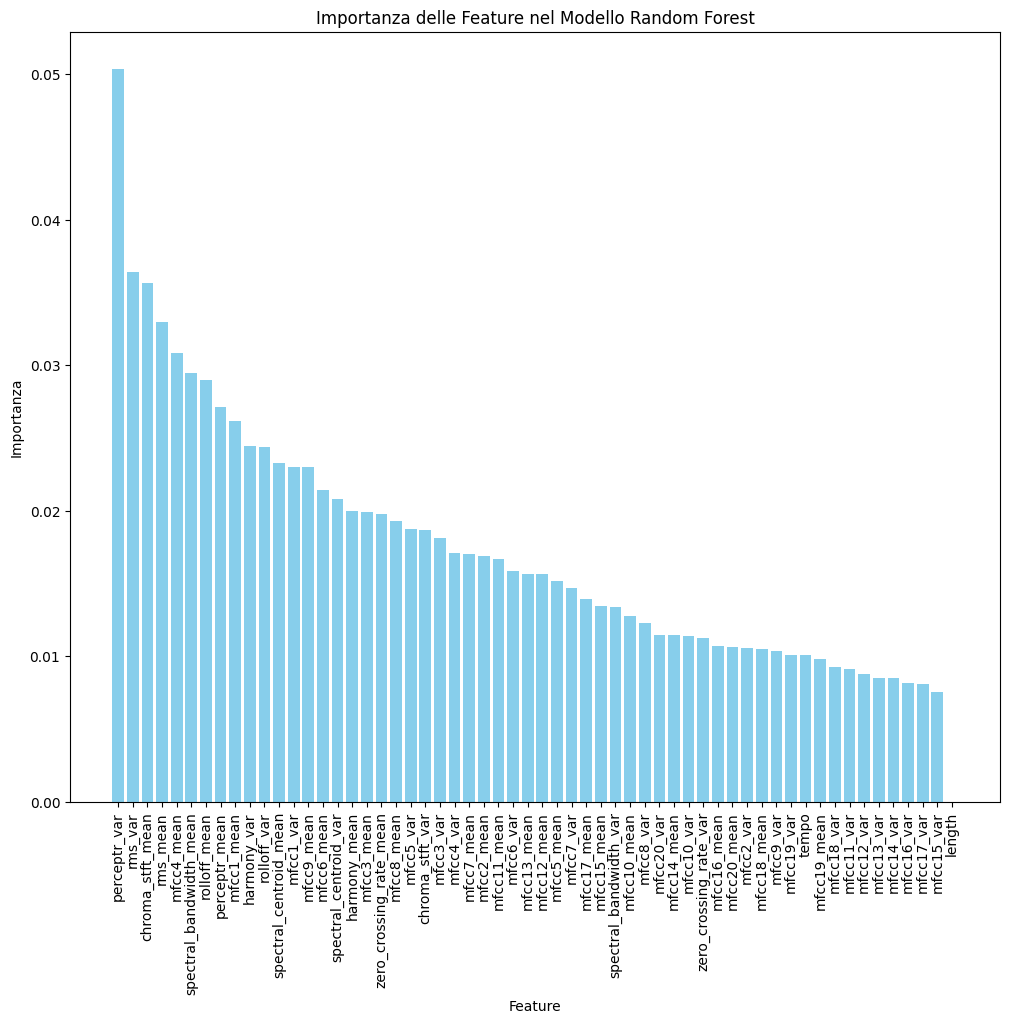

In [24]:



# Assicurati di non includere colonne non numeriche nel set di feature
X = music_data_original.drop(columns=['label', 'filename'])  # Rimuovi 'filename' e 'label'
y = music_data_original['label']

colonne=music_data_original.columns.size
print(colonne)

# Converti le etichette in numerico se necessario
y = y.astype('category').cat.codes  # Converte le etichette in numeri

# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modello Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Importanza delle feature
importances = rf.feature_importances_

# Creare un DataFrame per visualizzare l'importanza delle feature
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Grafico a barre verticale dell'importanza delle feature
plt.figure(figsize=(12, 10))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xticks(rotation=90)  # Ruota le etichette delle feature per leggibilità
plt.xlabel('Feature')
plt.ylabel('Importanza')
plt.title('Importanza delle Feature nel Modello Random Forest')
plt.show()


In [22]:
# Rimuovi le colonne non numeriche dal set di feature
X = music_data_original.drop(columns=['label', 'filename'])  # Rimuovi 'filename' e 'label'
y = music_data_original['label']

# Converti le etichette in numerico se necessario
y = y.astype('category').cat.codes  # Converte le etichette in numeri

# Divisione del dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # Crea e addestra il modello Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = rf.predict(X_test)

        # Calcolare l'accuratezza
        # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

        # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.8829
Precision: 0.8827
Recall: 0.8829
F1-score: 0.8814
F2-score: 0.8820
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.8829
Precision: 0.8827
Recall: 0.8829
F1-score: 0.8814
F2-score: 0.8820
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.8834
Precision: 0.8834
Recall: 0.8835
F1-score: 0.8819
F2-score: 0.8825
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.8819
Precision: 0.8817
Recall: 0.8819
F1-score: 0.8803
F2-score: 0.8810
------------------------------------------------------------


68
68


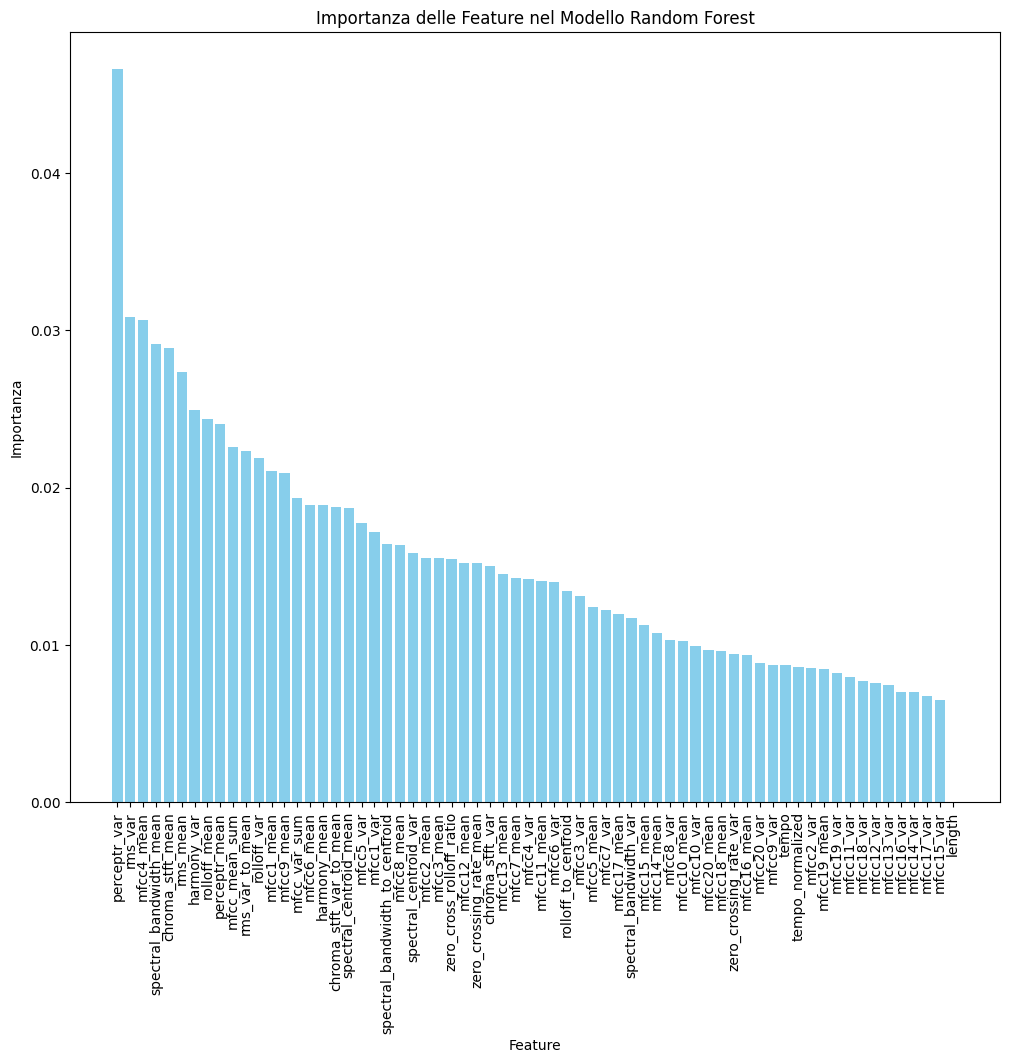

In [25]:
music_data_mod = pd.read_csv('Data/features_3_sec.csv') 

music_data_mod['rms_var_to_mean'] = music_data_mod['rms_var'] / music_data_mod['rms_mean']
music_data_mod['chroma_stft_var_to_mean'] = music_data_mod['chroma_stft_var'] / music_data_mod['chroma_stft_mean']
music_data_mod['rolloff_to_centroid'] = music_data_mod['rolloff_mean'] / music_data_mod['spectral_centroid_mean']
music_data_mod['spectral_bandwidth_to_centroid'] = music_data_mod['spectral_bandwidth_mean'] / music_data_mod['spectral_centroid_mean']
music_data_mod['mfcc_mean_sum'] = music_data_mod[[f'mfcc{i}_mean' for i in range(1, 21)]].sum(axis=1)
music_data_mod['mfcc_var_sum'] = music_data_mod[[f'mfcc{i}_var' for i in range(1, 21)]].sum(axis=1)
music_data_mod['tempo_normalized'] = music_data_mod['tempo'] / music_data_mod['length']
music_data_mod['zero_cross_rolloff_ratio'] = music_data_mod['zero_crossing_rate_mean'] / music_data_mod['rolloff_mean']

colonne=music_data_mod.columns.size
print(colonne)


# Assicurati di non includere colonne non numeriche nel set di feature
X = music_data_mod.drop(columns=['label', 'filename'])  # Rimuovi 'filename' e 'label'
y = music_data_mod['label']

colonne=music_data_mod.columns.size
print(colonne)

# Converti le etichette in numerico se necessario
y = y.astype('category').cat.codes  # Converte le etichette in numeri

# Divisione del dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modello Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# Importanza delle feature
importances = rf.feature_importances_

# Creare un DataFrame per visualizzare l'importanza delle feature
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Grafico a barre verticale dell'importanza delle feature
plt.figure(figsize=(12, 10))
plt.bar(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xticks(rotation=90)  # Ruota le etichette delle feature per leggibilità
plt.xlabel('Feature')
plt.ylabel('Importanza')
plt.title('Importanza delle Feature nel Modello Random Forest')
plt.show()


In [26]:
# Rimuovi le colonne non numeriche dal set di feature
X = music_data_mod.drop(columns=['label', 'filename'])  # Rimuovi 'filename' e 'label'
y = music_data_mod['label']

# Converti le etichette in numerico se necessario
y = y.astype('category').cat.codes  # Converte le etichette in numeri

# Divisione del dataset in training e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardizzare le caratteristiche
robust = RobustScaler()
standard = StandardScaler()
minmax = MinMaxScaler()
power = PowerTransformer()
scalers=[robust, standard, minmax, power]

for scaler in scalers:
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)


    # Crea e addestra il modello Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)

    # Prevedere le etichette per il set di test
    y_pred = rf.predict(X_test)

        # Calcolare l'accuratezza
        # Calcolare metriche
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='macro')  # Macro per bilanciare le classi
    recall = recall_score(y_test, y_pred, average='macro')
    f1 = f1_score(y_test, y_pred, average='macro')
    f2 = fbeta_score(y_test, y_pred, beta=2, average='macro')  # F2-score con beta=2

        # Stampare i risultati
    print(f'           Scaler: {scaler}')
    print(f'Accuratezza: {accuracy:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'F2-score: {f2:.4f}')
    # print(f'Hinge Loss: {loss}')
    print('------------------------------------------------------------')

           Scaler: RobustScaler()
Accuratezza: 0.8754
Precision: 0.8746
Recall: 0.8749
F1-score: 0.8737
F2-score: 0.8742
------------------------------------------------------------
           Scaler: StandardScaler()
Accuratezza: 0.8764
Precision: 0.8756
Recall: 0.8759
F1-score: 0.8747
F2-score: 0.8752
------------------------------------------------------------
           Scaler: MinMaxScaler()
Accuratezza: 0.8754
Precision: 0.8748
Recall: 0.8751
F1-score: 0.8738
F2-score: 0.8743
------------------------------------------------------------
           Scaler: PowerTransformer()
Accuratezza: 0.8754
Precision: 0.8745
Recall: 0.8750
F1-score: 0.8738
F2-score: 0.8743
------------------------------------------------------------
